<a href="https://colab.research.google.com/github/IremOzbek/Malaria_DINOv2-performansAnalizi/blob/main/DINOv2_Frozen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# MALARIA CLASSIFICATION USING DINOv2
# NIH MALARIA CELL IMAGES DATASET
# =====================================================

# =====================================================
# INSTALL REQUIRED PACKAGES
# =====================================================

!pip -q install kaggle
!pip -q install timm
!pip -q install torchmetrics
!pip -q install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.0 MB/s eta 0:00:00


In [2]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import os
import random
import zipfile
import shutil

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import timm

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

In [3]:
# =====================================================
# REPRODUCIBILITY
# =====================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# =====================================================
# DEVICE CHECK
# =====================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*50)
print("Device :", device)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    print(
        "Memory :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            /1024**3,
            2
        ),
        "GB"
    )

print("="*50)

Device : cuda
GPU : NVIDIA L4
Memory : 22.03 GB


In [5]:
# =====================================================
# KAGGLE API
# =====================================================

from google.colab import files

print("Upload kaggle.json")

uploaded = files.upload()
# =====================================================
# CONFIGURE KAGGLE
# =====================================================

!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API Ready.")

Upload kaggle.json


Saving kaggle.json to kaggle.json
Kaggle API Ready.


In [6]:
# =====================================================
# DOWNLOAD DATASET
# =====================================================

!kaggle datasets download \
-d iarunava/cell-images-for-detecting-malaria

print("Download completed.")

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:36<00:00, 19.3MB/s]

Download completed.


In [7]:
# =====================================================
# EXTRACT DATASET
# =====================================================

ZIP_PATH = "/content/cell-images-for-detecting-malaria.zip"

EXTRACT_PATH = "/content/malaria_dataset"

os.makedirs(
    EXTRACT_PATH,
    exist_ok=True
)

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as zip_ref:

    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted.")

Dataset extracted.


In [8]:
# =====================================================
# CHECK DATASET
# =====================================================

for root, dirs, files in os.walk(EXTRACT_PATH):

    print(root)

    if len(files) > 0:
        print("Files :", len(files))

    print("-"*40)

/content/malaria_dataset
----------------------------------------
/content/malaria_dataset/cell_images
----------------------------------------
/content/malaria_dataset/cell_images/cell_images
----------------------------------------
/content/malaria_dataset/cell_images/cell_images/Parasitized
Files : 13780
----------------------------------------
/content/malaria_dataset/cell_images/cell_images/Uninfected
Files : 13780
----------------------------------------
/content/malaria_dataset/cell_images/Parasitized
Files : 13780
----------------------------------------
/content/malaria_dataset/cell_images/Uninfected
Files : 13780
----------------------------------------


In [9]:
# =====================================================
# REMOVE NESTED CELL_IMAGES FOLDER
# =====================================================

import os
import shutil

nested_folder = "/content/malaria_dataset/cell_images/cell_images"

if os.path.exists(nested_folder):
    shutil.rmtree(nested_folder)
    print("Removed:", nested_folder)
else:
    print("Folder not found.")

Removed: /content/malaria_dataset/cell_images/cell_images


In [10]:
# =====================================================
# DATASET PATH
# =====================================================

DATASET_PATH = "/content/malaria_dataset/cell_images"

print(os.listdir(DATASET_PATH))

['Parasitized', 'Uninfected']


In [11]:
# =====================================================
# CLASS DISTRIBUTION
# =====================================================

classes = [
    "Parasitized",
    "Uninfected"
]

for cls in classes:

    folder = os.path.join(
        DATASET_PATH,
        cls
    )

    print(
        cls,
        len(os.listdir(folder))
    )

Parasitized 13780
Uninfected 13780


In [12]:
# =====================================================
# CREATE TRAIN VAL TEST SPLIT
# =====================================================

SPLIT_PATH = "/content/malaria_split"

for split in [
    "train",
    "val",
    "test"
]:

    for cls in classes:

        os.makedirs(
            os.path.join(
                SPLIT_PATH,
                split,
                cls
            ),
            exist_ok=True
        )

In [13]:
# =====================================================
# 80 / 10 / 10 SPLIT
# =====================================================

for cls in classes:

    src = os.path.join(
        DATASET_PATH,
        cls
    )

    images = os.listdir(src)

    train_imgs, temp_imgs = train_test_split(

        images,

        test_size=0.20,

        random_state=42,

        shuffle=True
    )

    val_imgs, test_imgs = train_test_split(

        temp_imgs,

        test_size=0.50,

        random_state=42,

        shuffle=True
    )

    split_dict = {

        "train":train_imgs,

        "val":val_imgs,

        "test":test_imgs
    }

    for split_name, img_list in split_dict.items():

        for img in img_list:

            shutil.copy(

                os.path.join(src,img),

                os.path.join(

                    SPLIT_PATH,

                    split_name,

                    cls,

                    img
                )
            )

print("Dataset split completed.")

Dataset split completed.


In [14]:
# =====================================================
# VERIFY SPLIT
# =====================================================

for split in [

    "train",

    "val",

    "test"

]:

    print("\n",split.upper())

    total = 0

    for cls in classes:

        path = os.path.join(

            SPLIT_PATH,

            split,

            cls
        )

        count = len(os.listdir(path))

        total += count

        print(cls, count)

    print("Total :", total)


 TRAIN
Parasitized 11024
Uninfected 11024
Total : 22048

 VAL
Parasitized 1378
Uninfected 1378
Total : 2756

 TEST
Parasitized 1378
Uninfected 1378
Total : 2756


In [15]:
# =====================================================
# IMAGE TRANSFORMS
# =====================================================

IMG_SIZE = 224

train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.5),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])


val_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

test_transform = val_transform

print("Transforms Ready")

Transforms Ready


In [16]:
# =====================================================
# IMAGEFOLDER DATASETS
# =====================================================

train_dataset = ImageFolder(

    root=os.path.join(
        SPLIT_PATH,
        "train"
    ),

    transform=train_transform
)

val_dataset = ImageFolder(

    root=os.path.join(
        SPLIT_PATH,
        "val"
    ),

    transform=val_transform
)

test_dataset = ImageFolder(

    root=os.path.join(
        SPLIT_PATH,
        "test"
    ),

    transform=test_transform
)

print("Train :", len(train_dataset))
print("Val :", len(val_dataset))
print("Test :", len(test_dataset))

print(train_dataset.classes)

Train : 22046
Val : 2756
Test : 2756
['Parasitized', 'Uninfected']


In [17]:
# =====================================================
# DATALOADERS
# =====================================================

BATCH_SIZE = 32

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True

)

print("DataLoaders Ready")

DataLoaders Ready


In [18]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

print(images.min())

print(images.max())

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(-2.1179)
tensor(2.2489)


In [19]:
print(
    timm.list_models("*dinov2*")
)

['vit_base_patch14_dinov2', 'vit_base_patch14_reg4_dinov2', 'vit_giant_patch14_dinov2', 'vit_giant_patch14_reg4_dinov2', 'vit_large_patch14_dinov2', 'vit_large_patch14_reg4_dinov2', 'vit_small_patch14_dinov2', 'vit_small_patch14_reg4_dinov2']


In [20]:
import timm

backbone = timm.create_model(
    "vit_base_patch14_dinov2",
    pretrained=True,
    img_size=224,
    num_classes=0
)

print(backbone.patch_embed.img_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

(224, 224)


In [21]:
import torch.nn as nn

class DinoClassifier(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.backbone = backbone

        self.head = nn.Sequential(

            nn.LayerNorm(backbone.num_features),

            nn.Linear(backbone.num_features, 512),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(512, 2)

        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.head(x)

        return x

In [22]:
model = DinoClassifier(backbone)

model = model.to(device)

print(model)

DinoClassifier(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
     

In [23]:
for param in model.backbone.parameters():

    param.requires_grad = False

print("Backbone Frozen")

Backbone Frozen


In [24]:
trainable = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

total = sum(

    p.numel()

    for p in model.parameters()

)

print(f"Trainable : {trainable:,}")

print(f"Total : {total:,}")

Trainable : 396,290
Total : 86,121,218


In [25]:
experiment_config = {

    "Model": "DINOv2 ViT-Base (Frozen)",

    "Dataset": "NIH Malaria Cell Images",

    "Train Split": "80%",

    "Validation Split": "10%",

    "Test Split": "10%",

    "Input Size": "224x224",

    "Batch Size": 32,

    "Epochs": 100,

    "Optimizer": "AdamW",

    "Learning Rate": 1e-4,

    "Weight Decay": 0.05,

    "Loss Function": "CrossEntropyLoss",

    "Scheduler": "ReduceLROnPlateau",

    "Early Stopping": 10,

    "Random Seed": 42

}

experiment_config

{'Model': 'DINOv2 ViT-Base (Frozen)',
 'Dataset': 'NIH Malaria Cell Images',
 'Train Split': '80%',
 'Validation Split': '10%',
 'Test Split': '10%',
 'Input Size': '224x224',
 'Batch Size': 32,
 'Epochs': 100,
 'Optimizer': 'AdamW',
 'Learning Rate': 0.0001,
 'Weight Decay': 0.05,
 'Loss Function': 'CrossEntropyLoss',
 'Scheduler': 'ReduceLROnPlateau',
 'Early Stopping': 10,
 'Random Seed': 42}

In [26]:
history = {

    "train_loss": [],

    "val_loss": [],

    "train_acc": [],

    "val_acc": [],

    "train_precision": [],

    "val_precision": [],

    "train_recall": [],

    "val_recall": [],

    "train_f1": [],

    "val_f1": [],

    "val_auc": [],

    "val_mcc": [],

    "learning_rate": []

}

In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-4,

    weight_decay=0.05

)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.1,

    patience=5

)

In [28]:
class EarlyStopping:

    def __init__(

        self,

        patience=10,

        save_path="best_dinov2.pth"

    ):

        self.patience = patience

        self.save_path = save_path

        self.best_loss = float("inf")

        self.counter = 0

        self.early_stop = False

    def __call__(

        self,

        val_loss,

        model

    ):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

            torch.save(

                model.state_dict(),

                self.save_path

            )

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True


early_stopping = EarlyStopping(
    patience=10
)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

import time

EPOCHS = 100

for epoch in range(EPOCHS):

    start_time = time.time()

    # =================================================
    # TRAIN
    # =================================================

    model.train()

    train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels.cpu().numpy()
        )

    train_loss /= len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    train_precision = precision_score(
        train_labels,
        train_preds,
        zero_division=0
    )

    train_recall = recall_score(
        train_labels,
        train_preds,
        zero_division=0
    )

    train_f1 = f1_score(
        train_labels,
        train_preds,
        zero_division=0
    )

    # =================================================
    # VALIDATION
    # =================================================

    model.eval()

    val_loss = 0

    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]

            preds = outputs.argmax(dim=1)

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_probs.extend(
                probs.cpu().numpy()
            )

    val_loss /= len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    val_precision = precision_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    val_f1 = f1_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    val_mcc = matthews_corrcoef(
        val_labels,
        val_preds
    )

    # =================================================
    # SAVE HISTORY
    # =================================================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["val_auc"].append(val_auc)
    history["val_mcc"].append(val_mcc)

    history["learning_rate"].append(
        optimizer.param_groups[0]["lr"]
    )

    # =================================================
    # Scheduler
    # =================================================

    scheduler.step(val_loss)

    # =================================================
    # Early Stopping
    # =================================================

    early_stopping(
        val_loss,
        model
    )

    epoch_time = time.time() - start_time

    print(

        f"[{epoch+1:03d}/{EPOCHS}] "

        f"TrainLoss={train_loss:.4f} "

        f"ValLoss={val_loss:.4f} "

        f"TrainAcc={train_acc:.4f} "

        f"ValAcc={val_acc:.4f} "

        f"Precision={val_precision:.4f} "

        f"Recall={val_recall:.4f} "

        f"F1={val_f1:.4f} "

        f"AUC={val_auc:.4f} "

        f"MCC={val_mcc:.4f} "

        f"LR={optimizer.param_groups[0]['lr']:.1e} "

        f"Time={epoch_time:.1f}s"

    )

    if early_stopping.early_stop:

        print("\nEarly stopping activated.")

        break

[001/100] TrainLoss=0.1385 ValLoss=0.1162 TrainAcc=0.9520 ValAcc=0.9604 Precision=0.9697 Recall=0.9507 F1=0.9601 AUC=0.9910 MCC=0.9211 LR=1.0e-04 Time=164.2s
[002/100] TrainLoss=0.1061 ValLoss=0.1084 TrainAcc=0.9619 ValAcc=0.9623 Precision=0.9596 Recall=0.9652 F1=0.9624 AUC=0.9921 MCC=0.9245 LR=1.0e-04 Time=164.4s
[003/100] TrainLoss=0.1014 ValLoss=0.1029 TrainAcc=0.9641 ValAcc=0.9634 Precision=0.9698 Recall=0.9565 F1=0.9631 AUC=0.9929 MCC=0.9268 LR=1.0e-04 Time=165.0s
[004/100] TrainLoss=0.0991 ValLoss=0.0969 TrainAcc=0.9632 ValAcc=0.9652 Precision=0.9612 Recall=0.9695 F1=0.9653 AUC=0.9934 MCC=0.9304 LR=1.0e-04 Time=164.7s
[005/100] TrainLoss=0.0927 ValLoss=0.1018 TrainAcc=0.9664 ValAcc=0.9630 Precision=0.9712 Recall=0.9543 F1=0.9627 AUC=0.9937 MCC=0.9261 LR=1.0e-04 Time=164.2s
[006/100] TrainLoss=0.0910 ValLoss=0.0940 TrainAcc=0.9669 ValAcc=0.9666 Precision=0.9659 Recall=0.9673 F1=0.9666 AUC=0.9939 MCC=0.9332 LR=1.0e-04 Time=164.7s
[007/100] TrainLoss=0.0895 ValLoss=0.1047 TrainAcc=0

In [30]:
model.load_state_dict(
    torch.load(
        "best_dinov2.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [31]:
test_preds = []
test_labels = []
test_probs = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )[:,1]

        preds = outputs.argmax(dim=1)

        test_preds.extend(
            preds.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

        test_probs.extend(
            probs.cpu().numpy()
        )

In [32]:
test_acc = accuracy_score(
    test_labels,
    test_preds
)

test_precision = precision_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_auc = roc_auc_score(
    test_labels,
    test_probs
)

test_mcc = matthews_corrcoef(
    test_labels,
    test_preds
)

print("="*60)

print(f"Accuracy  : {test_acc:.4f}")

print(f"Precision : {test_precision:.4f}")

print(f"Recall    : {test_recall:.4f}")

print(f"F1-score  : {test_f1:.4f}")

print(f"ROC-AUC   : {test_auc:.4f}")

print(f"MCC       : {test_mcc:.4f}")

print("="*60)

Accuracy  : 0.9695
Precision : 0.9723
Recall    : 0.9666
F1-score  : 0.9694
ROC-AUC   : 0.9946
MCC       : 0.9391


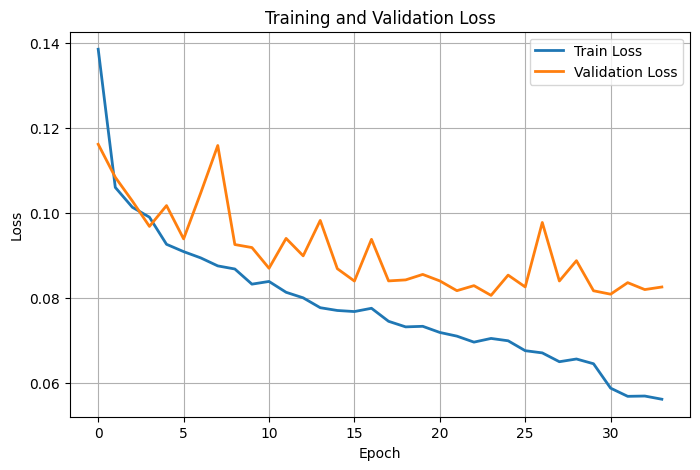

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

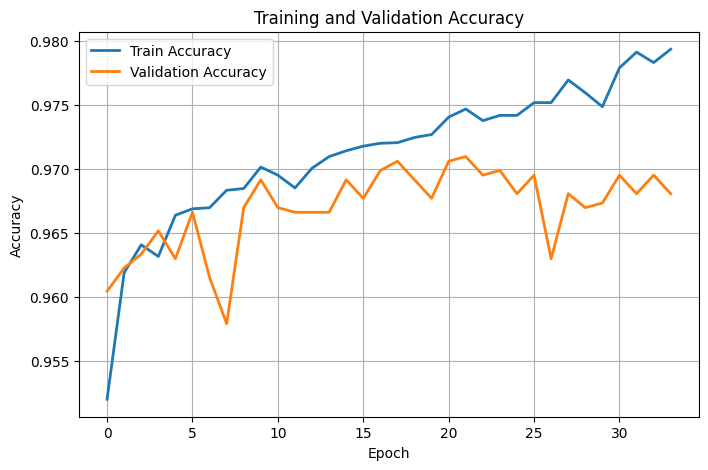

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

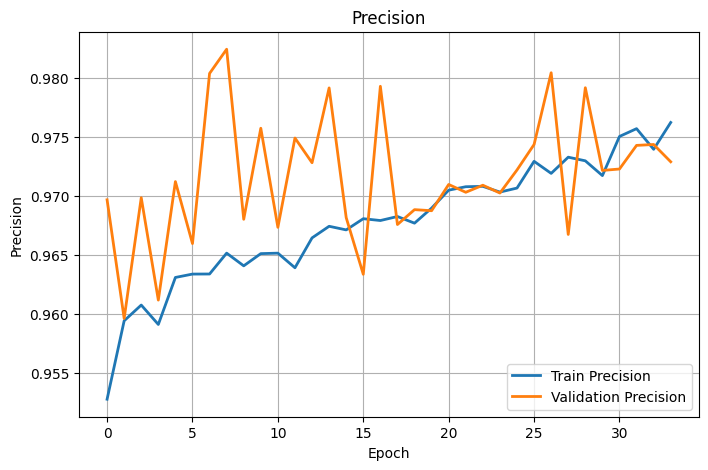

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_precision"],
    label="Train Precision",
    linewidth=2
)

plt.plot(
    history["val_precision"],
    label="Validation Precision",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Precision")

plt.title("Precision")

plt.legend()

plt.grid(True)

plt.show()

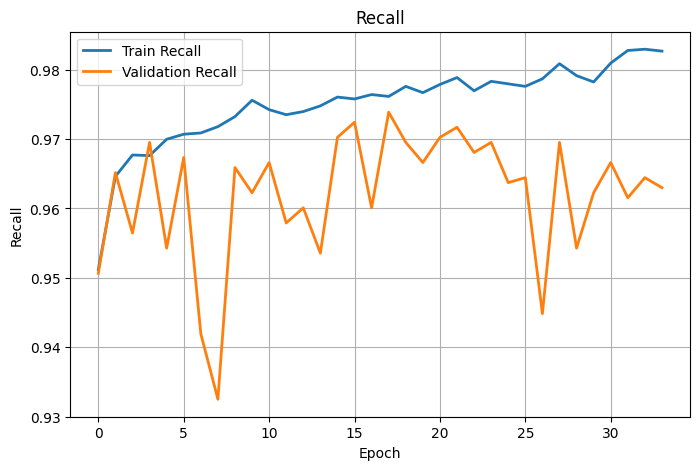

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_recall"],
    label="Train Recall",
    linewidth=2
)

plt.plot(
    history["val_recall"],
    label="Validation Recall",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Recall")

plt.title("Recall")

plt.legend()

plt.grid(True)

plt.show()

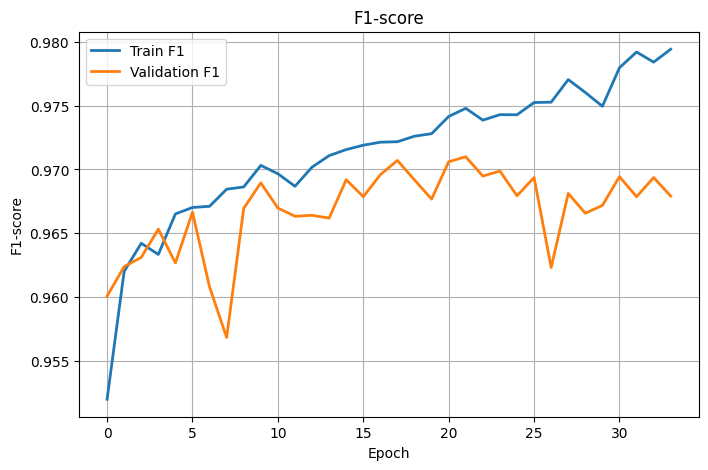

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_f1"],
    label="Train F1",
    linewidth=2
)

plt.plot(
    history["val_f1"],
    label="Validation F1",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("F1-score")

plt.title("F1-score")

plt.legend()

plt.grid(True)

plt.show()

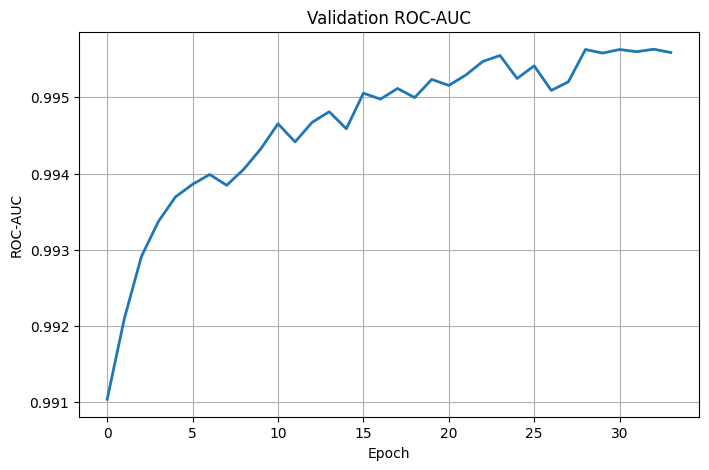

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    history["val_auc"],
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("ROC-AUC")

plt.title("Validation ROC-AUC")

plt.grid(True)

plt.show()

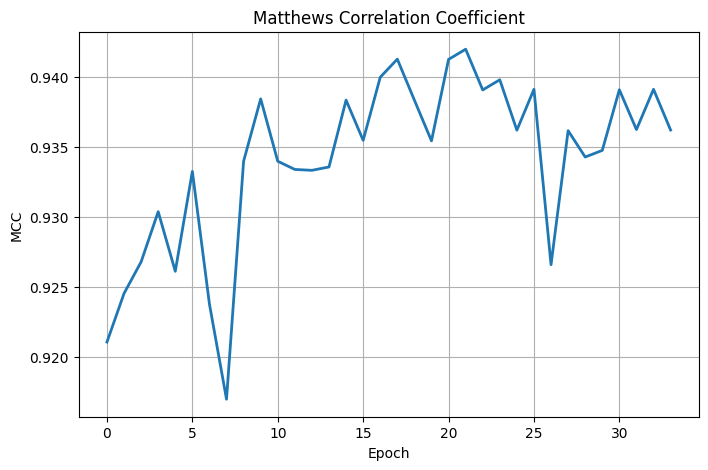

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    history["val_mcc"],
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("MCC")

plt.title("Matthews Correlation Coefficient")

plt.grid(True)

plt.show()

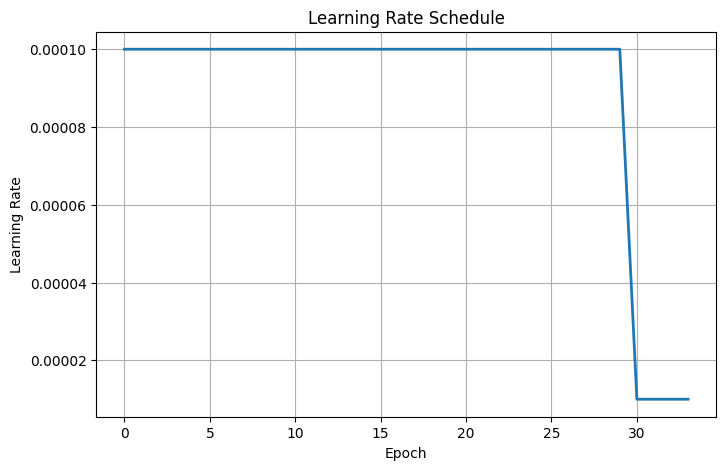

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    history["learning_rate"],
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Learning Rate")

plt.title("Learning Rate Schedule")

plt.grid(True)

plt.show()

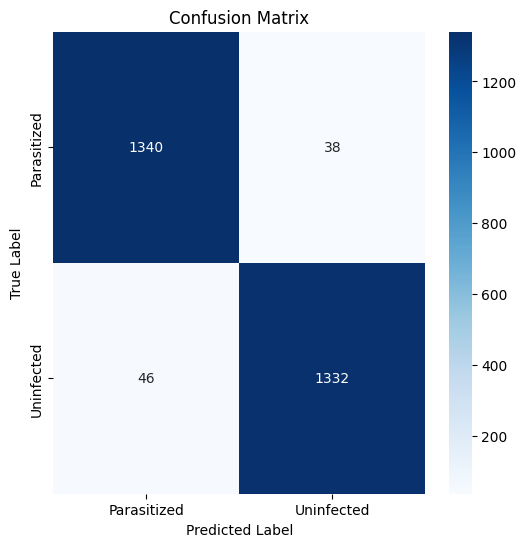

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    test_labels,
    test_preds
)

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Parasitized",
        "Uninfected"
    ],

    yticklabels=[
        "Parasitized",
        "Uninfected"
    ]

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

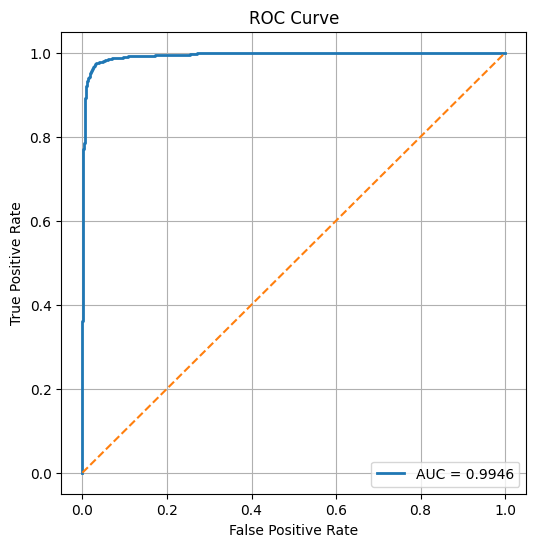

In [42]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {test_auc:.4f}"

)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [43]:
results = pd.DataFrame({

    "Accuracy":[test_acc],

    "Precision":[test_precision],

    "Recall":[test_recall],

    "F1":[test_f1],

    "ROC_AUC":[test_auc],

    "MCC":[test_mcc]

})

results

,Accuracy,Precision,Recall,F1,ROC_AUC,MCC
0,0.969521,0.972263,0.966618,0.969432,0.994603,0.939058


In [44]:
results.to_csv(
    "dinov2_results.csv",
    index=False
)

In [45]:
import gc
import torch

del model
del optimizer
del scheduler
del criterion

gc.collect()

torch.cuda.empty_cache()

print("Memory cleared.")

Memory cleared.


In [46]:
import timm
import torch.nn as nn

backbone = timm.create_model(
    "vit_base_patch14_dinov2",
    pretrained=True,
    num_classes=0
)

In [47]:
class DinoClassifier(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.backbone = backbone

        self.head = nn.Sequential(

            nn.LayerNorm(backbone.num_features),

            nn.Linear(backbone.num_features,512),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(512,2)

        )

    def forward(self,x):

        x = self.backbone(x)

        x = self.head(x)

        return x


model = DinoClassifier(backbone).to(device)

In [48]:
for param in model.backbone.parameters():

    param.requires_grad = False

In [49]:
for block in model.backbone.blocks[-3:]:

    for param in block.parameters():

        param.requires_grad = True

In [50]:
for param in model.backbone.norm.parameters():

    param.requires_grad = True

In [51]:
for param in model.head.parameters():

    param.requires_grad = True

In [52]:
trainable = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

total = sum(

    p.numel()

    for p in model.parameters()

)

print("Trainable:",trainable)

print("Total:",total)

print("Percentage:",
      trainable/total*100)

Trainable: 21666050
Total: 86976002
Percentage: 24.910377002612744


In [53]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    filter(
        lambda p:p.requires_grad,
        model.parameters()
    ),

    lr=1e-5,

    weight_decay=0.05

)

In [54]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.1,

    patience=5

)

In [55]:
early_stopping = EarlyStopping(

    patience=10,

    save_path="best_dinov2_finetuned.pth"

)

In [56]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": [],

    "val_auc": [],
    "val_mcc": [],

    "learning_rate": []

}

In [58]:
print(backbone.patch_embed.img_size)

(518, 518)


In [59]:
import gc

del model
del backbone

gc.collect()

torch.cuda.empty_cache()

In [60]:
backbone = timm.create_model(
    "vit_base_patch14_dinov2",
    pretrained=True,
    num_classes=0
)

print(backbone.patch_embed.img_size)

(518, 518)


In [61]:
print(timm.__version__)

1.0.27


In [62]:
backbone = timm.create_model(
    "vit_base_patch14_dinov2",
    pretrained=True,
    num_classes=0,
    img_size=224
)

In [63]:
print(backbone.patch_embed.img_size)

(224, 224)


In [65]:
import torch.nn as nn

class DinoClassifier(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.backbone = backbone

        self.head = nn.Sequential(

            nn.LayerNorm(backbone.num_features),

            nn.Linear(backbone.num_features, 512),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(512, 2)

        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.head(x)

        return x


model = DinoClassifier(backbone).to(device)

In [66]:
print(model.backbone.patch_embed.img_size)

(224, 224)


In [67]:
for p in model.backbone.parameters():
    p.requires_grad = False

for block in model.backbone.blocks[-3:]:
    for p in block.parameters():
        p.requires_grad = True

for p in model.backbone.norm.parameters():
    p.requires_grad = True

for p in model.head.parameters():
    p.requires_grad = True

In [68]:
optimizer = torch.optim.AdamW(

    filter(lambda p: p.requires_grad, model.parameters()),

    lr=1e-5,

    weight_decay=0.05

)

In [69]:
images, labels = next(iter(train_loader))

print(images.shape)

print(model.backbone.patch_embed.img_size)

out = model(images.to(device))

print(out.shape)

torch.Size([32, 3, 224, 224])
(224, 224)
torch.Size([32, 2])


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

import time

EPOCHS = 100

for epoch in range(EPOCHS):

    start_time = time.time()

    # =================================================
    # TRAIN
    # =================================================

    model.train()

    train_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels.cpu().numpy()
        )

    train_loss /= len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    train_precision = precision_score(
        train_labels,
        train_preds,
        zero_division=0
    )

    train_recall = recall_score(
        train_labels,
        train_preds,
        zero_division=0
    )

    train_f1 = f1_score(
        train_labels,
        train_preds,
        zero_division=0
    )

    # =================================================
    # VALIDATION
    # =================================================

    model.eval()

    val_loss = 0

    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            probs = torch.softmax(
                outputs,
                dim=1
            )[:,1]

            preds = outputs.argmax(dim=1)

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

            val_probs.extend(
                probs.cpu().numpy()
            )

    val_loss /= len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    val_precision = precision_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    val_recall = recall_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    val_f1 = f1_score(
        val_labels,
        val_preds,
        zero_division=0
    )

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    val_mcc = matthews_corrcoef(
        val_labels,
        val_preds
    )

    # =================================================
    # SAVE HISTORY
    # =================================================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["val_auc"].append(val_auc)
    history["val_mcc"].append(val_mcc)

    history["learning_rate"].append(
        optimizer.param_groups[0]["lr"]
    )

    # =================================================
    # Scheduler
    # =================================================

    scheduler.step(val_loss)

    # =================================================
    # Early Stopping
    # =================================================

    early_stopping(
        val_loss,
        model
    )

    epoch_time = time.time() - start_time

    print(

        f"[{epoch+1:03d}/{EPOCHS}] "

        f"TrainLoss={train_loss:.4f} "

        f"ValLoss={val_loss:.4f} "

        f"TrainAcc={train_acc:.4f} "

        f"ValAcc={val_acc:.4f} "

        f"Precision={val_precision:.4f} "

        f"Recall={val_recall:.4f} "

        f"F1={val_f1:.4f} "

        f"AUC={val_auc:.4f} "

        f"MCC={val_mcc:.4f} "

        f"LR={optimizer.param_groups[0]['lr']:.1e} "

        f"Time={epoch_time:.1f}s"

    )

    if early_stopping.early_stop:

        print("\nEarly stopping activated.")

        break

[001/100] TrainLoss=0.1062 ValLoss=0.0828 TrainAcc=0.9611 ValAcc=0.9699 Precision=0.9642 Recall=0.9761 F1=0.9701 AUC=0.9951 MCC=0.9398 LR=1.0e-05 Time=230.6s
[002/100] TrainLoss=0.0780 ValLoss=0.0754 TrainAcc=0.9719 ValAcc=0.9753 Precision=0.9795 Recall=0.9710 F1=0.9752 AUC=0.9964 MCC=0.9507 LR=1.0e-05 Time=232.4s
[003/100] TrainLoss=0.0688 ValLoss=0.0747 TrainAcc=0.9745 ValAcc=0.9728 Precision=0.9697 Recall=0.9761 F1=0.9729 AUC=0.9961 MCC=0.9456 LR=1.0e-05 Time=232.6s
[004/100] TrainLoss=0.0616 ValLoss=0.0779 TrainAcc=0.9776 ValAcc=0.9739 Precision=0.9739 Recall=0.9739 F1=0.9739 AUC=0.9967 MCC=0.9478 LR=1.0e-05 Time=232.0s
[005/100] TrainLoss=0.0556 ValLoss=0.0801 TrainAcc=0.9794 ValAcc=0.9721 Precision=0.9745 Recall=0.9695 F1=0.9720 AUC=0.9965 MCC=0.9441 LR=1.0e-05 Time=232.0s
[006/100] TrainLoss=0.0519 ValLoss=0.0779 TrainAcc=0.9807 ValAcc=0.9713 Precision=0.9800 Recall=0.9623 F1=0.9711 AUC=0.9967 MCC=0.9428 LR=1.0e-05 Time=232.0s
[007/100] TrainLoss=0.0441 ValLoss=0.0762 TrainAcc=0

In [71]:
model.load_state_dict(
    torch.load(
        "best_dinov2_finetuned.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

model.eval()

test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(dim=1)

        test_preds.extend(
            preds.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

        test_probs.extend(
            probs[:,1].cpu().numpy()
        )

In [73]:
test_acc = accuracy_score(
    test_labels,
    test_preds
)

test_precision = precision_score(
    test_labels,
    test_preds
)

test_recall = recall_score(
    test_labels,
    test_preds
)

test_f1 = f1_score(
    test_labels,
    test_preds
)

test_auc = roc_auc_score(
    test_labels,
    test_probs
)

test_mcc = matthews_corrcoef(
    test_labels,
    test_preds
)

In [74]:
print("="*60)

print(f"Accuracy  : {test_acc:.4f}")

print(f"Precision : {test_precision:.4f}")

print(f"Recall    : {test_recall:.4f}")

print(f"F1-score  : {test_f1:.4f}")

print(f"ROC-AUC   : {test_auc:.4f}")

print(f"MCC       : {test_mcc:.4f}")

print("="*60)

Accuracy  : 0.9790
Precision : 0.9728
Recall    : 0.9855
F1-score  : 0.9791
ROC-AUC   : 0.9965
MCC       : 0.9580


In [75]:
from sklearn.metrics import classification_report

print(

    classification_report(

        test_labels,

        test_preds,

        target_names=[
            "Parasitized",
            "Uninfected"
        ]

    )

)

              precision    recall  f1-score   support

 Parasitized       0.99      0.97      0.98      1378
  Uninfected       0.97      0.99      0.98      1378

    accuracy                           0.98      2756
   macro avg       0.98      0.98      0.98      2756
weighted avg       0.98      0.98      0.98      2756



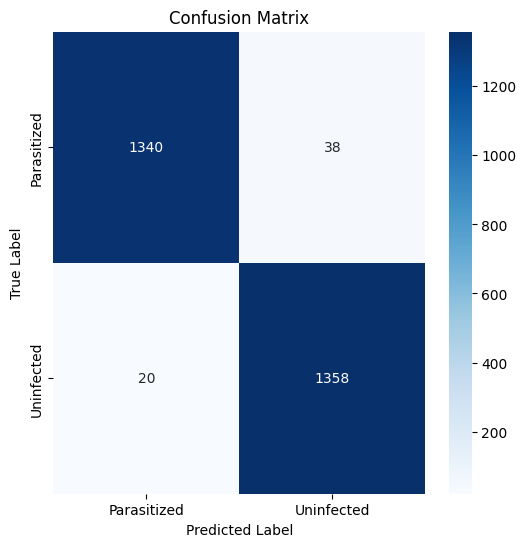

In [76]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    test_labels,
    test_preds
)

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Parasitized",
        "Uninfected"
    ],

    yticklabels=[
        "Parasitized",
        "Uninfected"
    ]

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

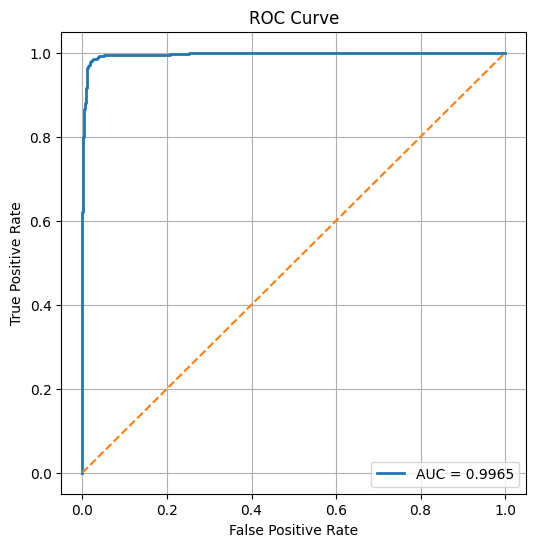

In [77]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    test_labels,
    test_probs
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {test_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [78]:
import pandas as pd

results = pd.DataFrame({

    "Model":["DINOv2 Fine-Tuned"],

    "Accuracy":[test_acc],

    "Precision":[test_precision],

    "Recall":[test_recall],

    "F1":[test_f1],

    "ROC_AUC":[test_auc],

    "MCC":[test_mcc]

})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,MCC
0,DINOv2 Fine-Tuned,0.978955,0.972779,0.985486,0.979092,0.996468,0.957992


In [79]:
results.to_csv(

    "dinov2_finetuned_results.csv",

    index=False

)

print("Results saved successfully.")

Results saved successfully.


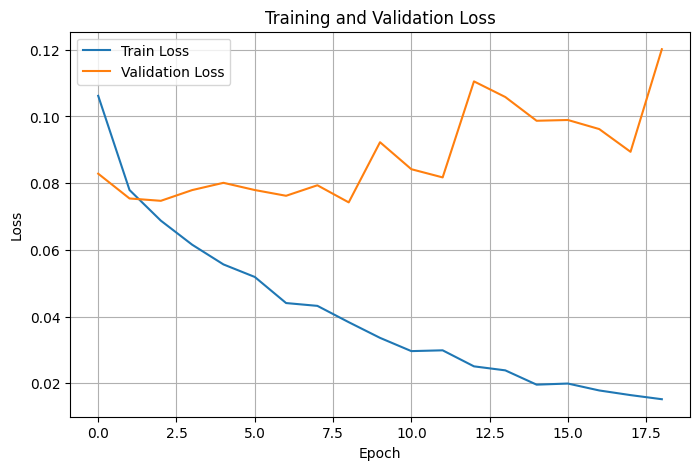

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

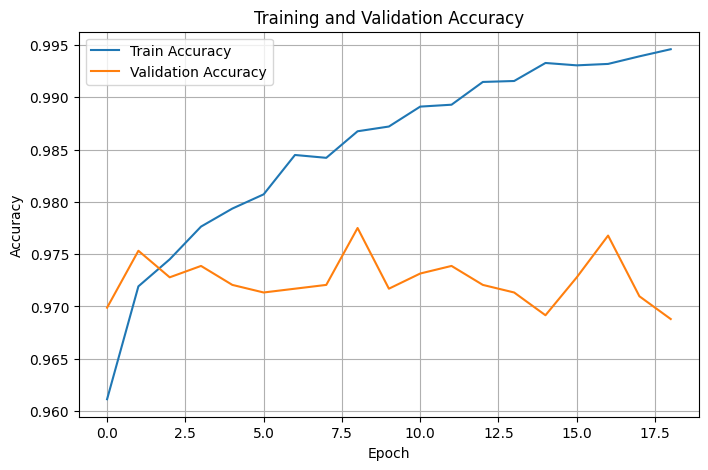

In [82]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

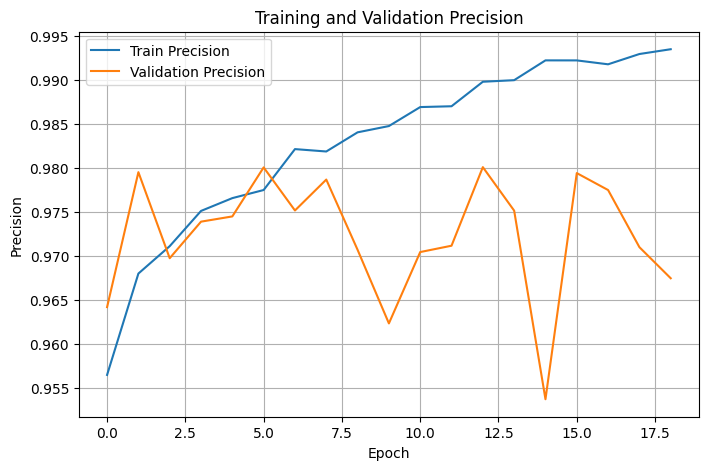

In [83]:
plt.figure(figsize=(8,5))

plt.plot(history["train_precision"], label="Train Precision")
plt.plot(history["val_precision"], label="Validation Precision")

plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training and Validation Precision")

plt.legend()

plt.grid(True)

plt.show()

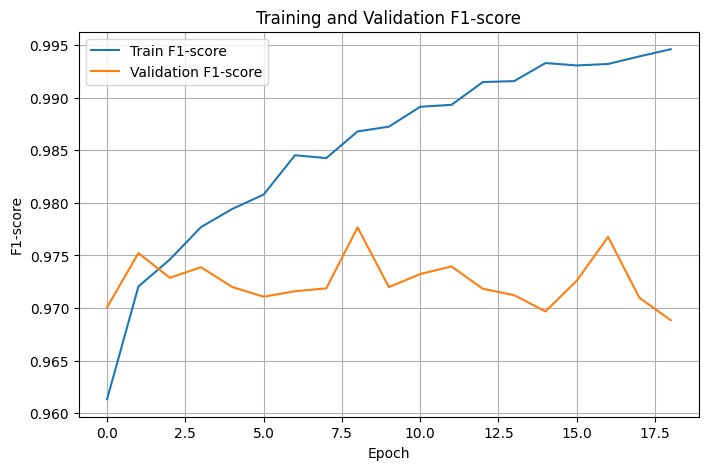

In [84]:
plt.figure(figsize=(8,5))

plt.plot(history["train_f1"], label="Train F1-score")
plt.plot(history["val_f1"], label="Validation F1-score")

plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training and Validation F1-score")

plt.legend()

plt.grid(True)

plt.show()

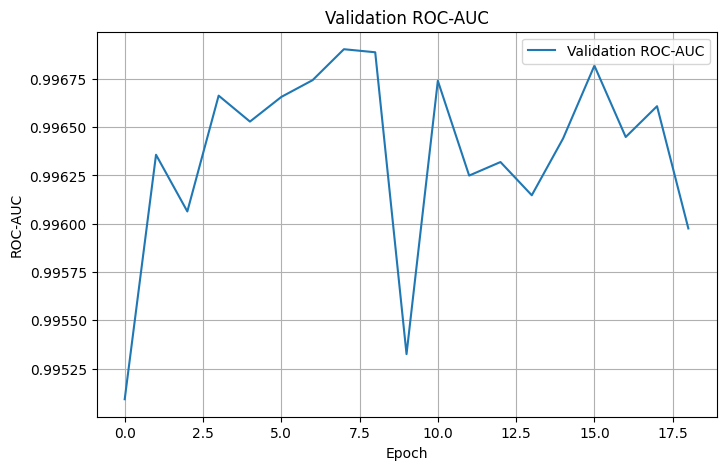

In [85]:
plt.figure(figsize=(8,5))

plt.plot(history["val_auc"], label="Validation ROC-AUC")

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Validation ROC-AUC")

plt.legend()

plt.grid(True)

plt.show()

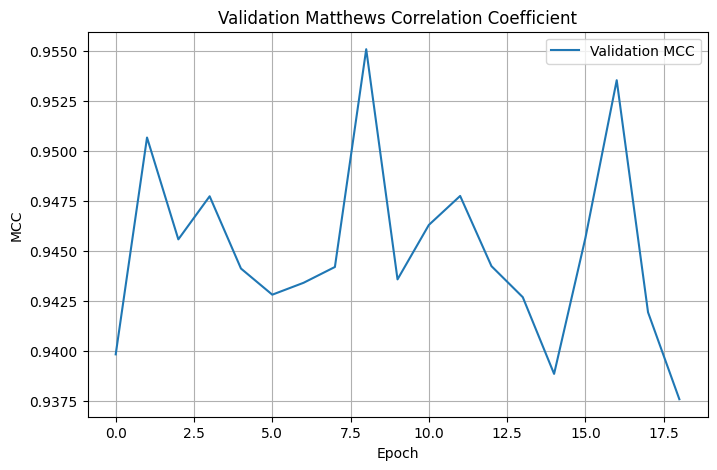

In [86]:
plt.figure(figsize=(8,5))

plt.plot(history["val_mcc"], label="Validation MCC")

plt.xlabel("Epoch")
plt.ylabel("MCC")
plt.title("Validation Matthews Correlation Coefficient")

plt.legend()

plt.grid(True)

plt.show()

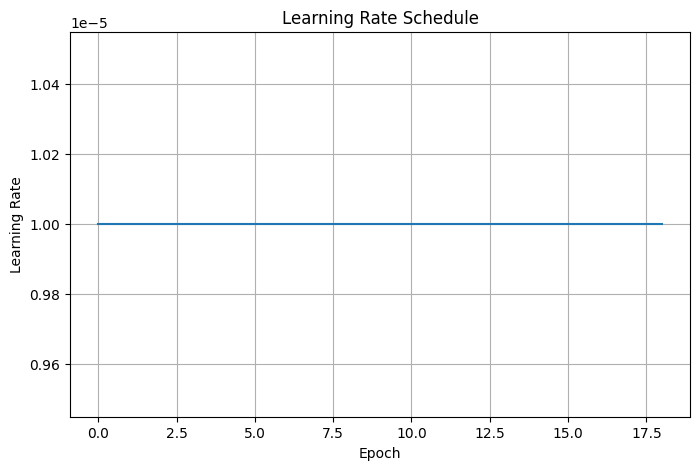

In [87]:
plt.figure(figsize=(8,5))

plt.plot(history["learning_rate"])

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title("Learning Rate Schedule")

plt.grid(True)

plt.show()

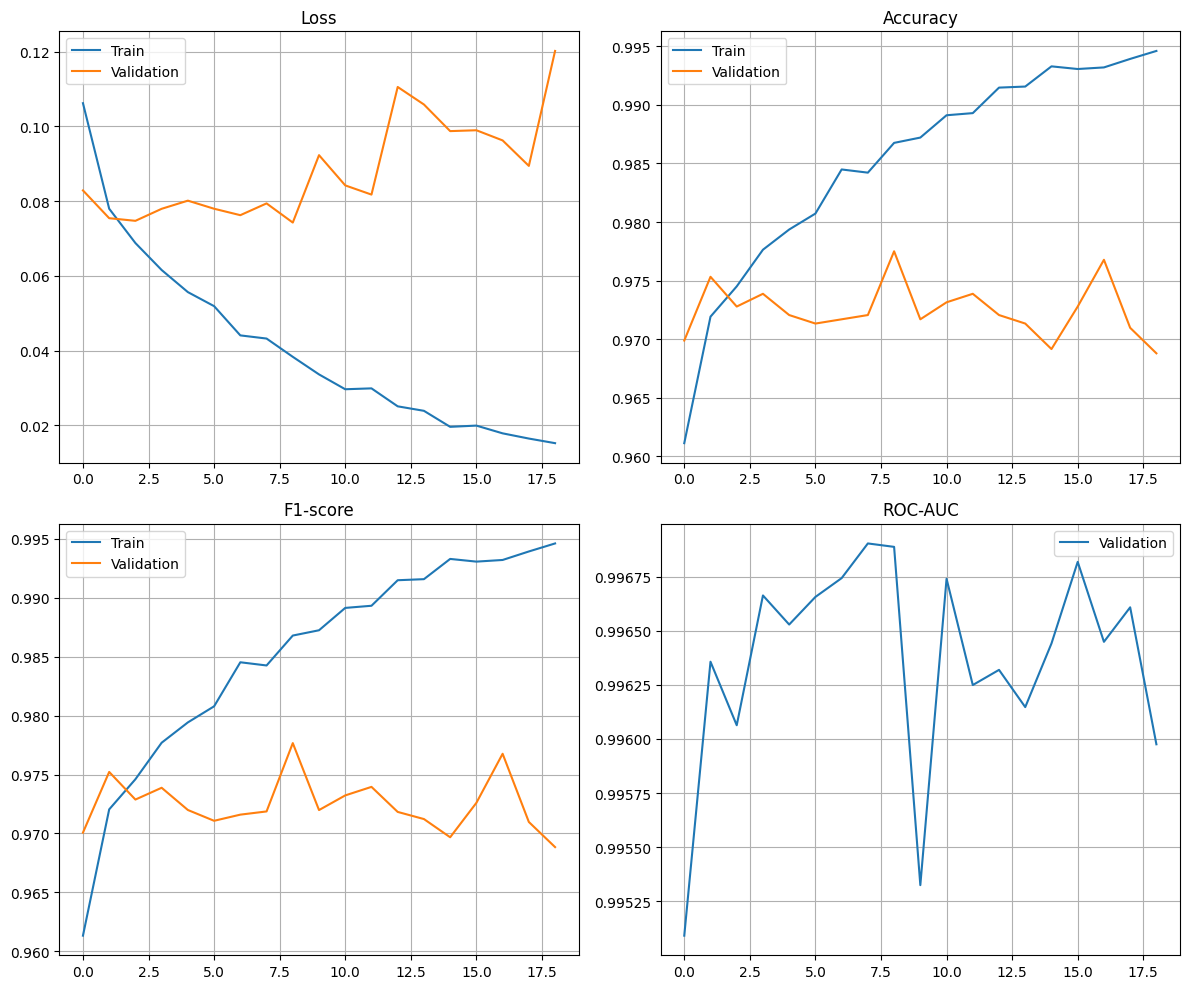

In [88]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Loss
axes[0,0].plot(history["train_loss"], label="Train")
axes[0,0].plot(history["val_loss"], label="Validation")
axes[0,0].set_title("Loss")
axes[0,0].legend()
axes[0,0].grid(True)

# Accuracy
axes[0,1].plot(history["train_acc"], label="Train")
axes[0,1].plot(history["val_acc"], label="Validation")
axes[0,1].set_title("Accuracy")
axes[0,1].legend()
axes[0,1].grid(True)

# F1-score
axes[1,0].plot(history["train_f1"], label="Train")
axes[1,0].plot(history["val_f1"], label="Validation")
axes[1,0].set_title("F1-score")
axes[1,0].legend()
axes[1,0].grid(True)

# ROC-AUC
axes[1,1].plot(history["val_auc"], label="Validation")
axes[1,1].set_title("ROC-AUC")
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()

plt.show()